In [1]:
# Imports and configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

from networks import load_arm
from modelling import split_train_test
import embedding_geometry as eg
from plot_style import (
    set_publication_style, style_axis, format_date_axis, add_panel_label, shade_periods,
    REGIME_PALETTE, NEUTRAL_COLOURS, CRISIS_EVENTS,
)

INDEX_CODE = "SP500"
ARM = "raw"
EPOCH_LENGTH = 132
GRAPH_TYPE = "mst"
GRAPH_KEY = "mst_threshold_graphs"
BUNDLE_TAG = f"{INDEX_CODE}_{ARM}_{EPOCH_LENGTH}d_{GRAPH_TYPE}"
MODELS_DIR = "outputs/models"
TRAIN_TEST_CUTOFF = "2019-12-31"
REGIME_NAMES = ["Calm", "Transitional", "Crisis"]
TRADING_DAYS_PER_YEAR = 252
ROLLING_SHARPE_WINDOW = 126
STRATEGY_COLOURS = {"Buy-and-hold": "#7570b3", "Regime-timed": "#1b9e77"}

set_publication_style()

In [2]:
# Replay the frozen bundle on the test-period MST-threshold graphs to recover mu-ranked K-means labels
data = load_arm(ARM, EPOCH_LENGTH, index_code=INDEX_CODE)
train, test = split_train_test(data, cutoff=TRAIN_TEST_CUTOFF)
train_graphs, test_graphs = train[GRAPH_KEY], test[GRAPH_KEY]

bundle, train_raw, test_raw, train_oov, test_oov = eg.load_graph2vec_raw(BUNDLE_TAG, train_graphs, test_graphs, MODELS_DIR)
n_train = len(train_graphs)
all_labels = eg.raw_arm_regime_labels(bundle, test_raw, n_train)
test_label_ids = all_labels[n_train:]

test_dates = pd.DatetimeIndex(pd.to_datetime(test["epoch_dates"]))
regime_labels = pd.Series(np.array(REGIME_NAMES)[test_label_ids], index=test_dates, name="regime")

print(f"{len(test_dates)} test windows, {test_dates[0].date()} to {test_dates[-1].date()}")
regime_labels.value_counts()

164 test windows, 2020-01-07 to 2026-07-06


regime
Calm            70
Transitional    49
Crisis          45
Name: count, dtype: int64

In [3]:
# Load the cleaned S&P 500 panel and compute simple returns, restricted to the test period
prices = pd.read_csv("data/SP500_AdjClose_Cleaned.csv")
prices["Date"] = pd.to_datetime(prices["Date"])
prices = prices.set_index("Date").sort_index()

returns = prices.pct_change().iloc[1:]
returns_test = returns.loc[returns.index > test_dates[0]]

print(f"return panel: {returns_test.shape[0]} days x {returns_test.shape[1]} stocks, "
      f"{returns_test.index[0].date()} to {returns_test.index[-1].date()}")
returns_test.head()

return panel: 1636 days x 349 stocks, 2020-01-08 to 2026-07-14


,HC_A,IT_AAPL,HC_ABT,FIN_ACGL,IT_ADBE,IT_ADI,CST_ADM,UTL_AEE,UTL_AEP,UTL_AES,...,FIN_WFC,IND_WM,CST_WMT,FIN_WRB,CD_WSM,HC_WST,RE_WY,UTL_XEL,CD_YUM,IT_ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-08,0.009873,0.016086,0.004077,-0.009963,0.013438,0.009032,-0.011084,-0.001700,-0.002988,-0.001991,...,0.003038,0.000603,-0.003432,0.007091,0.006643,-0.013502,0.003769,-0.000961,0.001765,-0.034429
2020-01-09,0.015712,0.021241,0.002668,0.020360,0.007636,0.000000,-0.010312,0.003801,0.005032,0.009970,...,-0.001704,0.000431,0.010330,0.005868,0.011448,0.011217,0.008191,0.002244,0.007930,-0.004603
2020-01-10,0.003667,0.002261,-0.012494,-0.001605,-0.001880,-0.017322,-0.004530,0.005484,0.004900,-0.003949,...,-0.004362,0.000603,-0.008350,-0.010354,-0.009721,0.007725,0.001015,0.001599,-0.012335,-0.000933
2020-01-13,-0.001484,0.021364,-0.002811,0.003676,0.017127,0.004132,0.010694,0.008051,0.003074,0.006442,...,-0.007428,0.012564,-0.004296,0.003684,0.015464,0.021686,0.022996,0.011654,-0.013276,0.009380
2020-01-14,0.006060,-0.013503,0.011562,-0.000458,-0.002893,0.003948,0.001801,-0.000258,0.003699,0.004431,...,-0.053924,0.003484,0.002589,0.002643,0.006488,0.003527,0.012892,0.001578,0.003787,-0.002052


In [4]:
# Idle capital is assumed to earn a constant annual risk-free rate, avoiding a second downloaded time series
RISK_FREE_RATE_ANNUAL = 0.025
risk_free_daily = (1 + RISK_FREE_RATE_ANNUAL) ** (1 / TRADING_DAYS_PER_YEAR) - 1

print(f"assumed constant risk-free rate: {RISK_FREE_RATE_ANNUAL:.2%} annual "
      f"({risk_free_daily * 100:.4f}% daily simple), close to the sample-period average 13-week T-bill yield")

assumed constant risk-free rate: 2.50% annual (0.0098% daily simple), close to the sample-period average 13-week T-bill yield


In [5]:
# Functions: buy-and-hold equal-weight equity sleeve (no rebalancing), combine exposure/cash into a portfolio return, and split realised return into equity vs. cash-carry contribution
def equal_weight_drift_returns(returns_df):
    n = returns_df.shape[1]
    weights = np.full(n, 1.0 / n)
    port_returns = []
    for _, row in returns_df.iterrows():
        day_returns = row.to_numpy()
        port_returns.append(float(np.dot(weights, day_returns)))
        weights = weights * (1.0 + day_returns)
        weights = weights / weights.sum()
    return pd.Series(port_returns, index=returns_df.index, name="eq_weighted_return")


def portfolio_return(exposure, r_eq, r_f):
    return exposure * r_eq + (1 - exposure) * r_f


def carry_decomposition(exposure, r_eq, r_f):
    total = (1 + portfolio_return(exposure, r_eq, r_f)).prod() - 1
    no_carry = (1 + exposure * r_eq).prod() - 1
    return total, no_carry, total - no_carry

In [6]:
# Build the equal-weight equity sleeve once, bought on the first test-period day and held with no rebalancing thereafter
eq_weighted_test = equal_weight_drift_returns(returns_test)
assert eq_weighted_test.std() > 0.001, "equal-weighted return series looks degenerate -- check the price panel"
print(f"equal-weighted buy-and-hold sleeve simulated over {len(eq_weighted_test)} test-period days, no rebalancing")

equal-weighted buy-and-hold sleeve simulated over 1636 test-period days, no rebalancing


In [7]:
# Raw (unlagged) exposure schedules for the two strategies
EXPOSURE_MAP = {"Calm": 1.00, "Transitional": 0.50, "Crisis": 0.00}

full_dates = pd.DatetimeIndex([test_dates[0]]).append(returns_test.index)
regime_daily_full = regime_labels.reindex(regime_labels.index.union(full_dates)).sort_index().ffill().reindex(full_dates)
window_date_daily_full = pd.Series(regime_labels.index, index=regime_labels.index)
window_date_daily_full = window_date_daily_full.reindex(window_date_daily_full.index.union(full_dates)).sort_index().ffill().reindex(full_dates)

raw_exposure_A = pd.Series(1.0, index=full_dates)
raw_exposure_B = regime_daily_full.map(EXPOSURE_MAP)

print("raw exposure schedules built for", len(full_dates), "dates (window end date plus every test-period trading day)")

raw exposure schedules built for 1637 dates (window end date plus every test-period trading day)


In [8]:
# Shift every raw exposure series forward one trading day, then preview the resulting portfolio-return alignment
lagged_exposure_A = raw_exposure_A.shift(1).reindex(returns_test.index)
lagged_exposure_B = raw_exposure_B.shift(1).reindex(returns_test.index)

preview_return_B = portfolio_return(lagged_exposure_B, eq_weighted_test, risk_free_daily)

alignment = pd.DataFrame({
    "window_end_date_in_force": window_date_daily_full.reindex(returns_test.index).dt.date,
    "regime": regime_daily_full.reindex(returns_test.index),
    "raw_exposure_B": raw_exposure_B.reindex(returns_test.index),
    "lagged_exposure_B": lagged_exposure_B,
    "equal_weighted_return": eq_weighted_test,
    "portfolio_return_B": preview_return_B,
})
alignment.index.name = "date"
alignment.head(15)

,window_end_date_in_force,regime,raw_exposure_B,lagged_exposure_B,equal_weighted_return,portfolio_return_B
date,,,,,,
2020-01-08,2020-01-07,Transitional,0.5,0.5,0.002983,0.001540
2020-01-09,2020-01-07,Transitional,0.5,0.5,0.005032,0.002565
2020-01-10,2020-01-07,Transitional,0.5,0.5,-0.002130,-0.001016
2020-01-13,2020-01-07,Transitional,0.5,0.5,0.007333,0.003715
2020-01-14,2020-01-07,Transitional,0.5,0.5,0.001201,0.000650
2020-01-15,2020-01-07,Transitional,0.5,0.5,0.002127,0.001113
2020-01-16,2020-01-07,Transitional,0.5,0.5,0.008877,0.004488
2020-01-17,2020-01-07,Transitional,0.5,0.5,0.002734,0.001416
2020-01-21,2020-01-07,Transitional,0.5,0.5,-0.002789,-0.001346


In [9]:
# Same table, centred on the first Crisis transition in the test period
first_crisis_pos = alignment.index.get_indexer([alignment[alignment["regime"] == "Crisis"].index[0]])[0]
alignment.iloc[max(0, first_crisis_pos - 7):first_crisis_pos + 8]

,window_end_date_in_force,regime,raw_exposure_B,lagged_exposure_B,equal_weighted_return,portfolio_return_B
date,,,,,,
2020-03-10,2020-03-05,Transitional,0.5,0.5,0.043996,0.022047
2020-03-11,2020-03-05,Transitional,0.5,0.5,-0.053397,-0.026650
2020-03-12,2020-03-05,Transitional,0.5,0.5,-0.098618,-0.049260
2020-03-13,2020-03-05,Transitional,0.5,0.5,0.080081,0.040090
2020-03-16,2020-03-05,Transitional,0.5,0.5,-0.119118,-0.059510
2020-03-17,2020-03-05,Transitional,0.5,0.5,0.063831,0.031964
2020-03-18,2020-03-05,Transitional,0.5,0.5,-0.064092,-0.031997
2020-03-19,2020-03-19,Crisis,0.0,0.5,0.002654,0.001376
2020-03-20,2020-03-19,Crisis,0.0,0.0,-0.046823,0.000098


In [10]:
# Gross (zero-cost) portfolio return series for both strategies
gross_return_A = portfolio_return(lagged_exposure_A, eq_weighted_test, risk_free_daily)
gross_return_B = portfolio_return(lagged_exposure_B, eq_weighted_test, risk_free_daily)

STRATEGIES = {"Buy-and-hold": (lagged_exposure_A, gross_return_A),
              "Regime-timed": (lagged_exposure_B, gross_return_B)}
print("cumulative gross return:")
for name, (exposure, ret) in STRATEGIES.items():
    print(f"  {name:15s} {(1 + ret).prod() - 1:+.2%}")

cumulative gross return:
  Buy-and-hold    +168.76%
  Regime-timed    +57.70%


In [11]:
# Cash-carry vs. timing decomposition: how much of each strategy's return is earned at the assumed risk-free rate while out of equity
carry_rows = []
for name, (exposure, _) in STRATEGIES.items():
    total, no_carry, carry = carry_decomposition(exposure, eq_weighted_test, risk_free_daily)
    carry_rows.append({"strategy": name, "total_return": total, "return_ex_carry": no_carry, "carry_contribution": carry})
pd.DataFrame(carry_rows).set_index("strategy")

,total_return,return_ex_carry,carry_contribution
strategy,,,
Buy-and-hold,1.687617,1.687617,0.000000
Regime-timed,0.576979,0.473163,0.103816


In [12]:
# Functions: CAGR, annualised volatility, Sharpe ratio (excess over the assumed risk-free rate), max drawdown, Calmar ratio, and turnover
def cagr(returns, periods_per_year=TRADING_DAYS_PER_YEAR):
    n_years = len(returns) / periods_per_year
    return (1 + returns).prod() ** (1 / n_years) - 1


def annualised_vol(returns, periods_per_year=TRADING_DAYS_PER_YEAR):
    return returns.std() * np.sqrt(periods_per_year)


def sharpe_ratio(returns, r_f, periods_per_year=TRADING_DAYS_PER_YEAR):
    excess = returns - r_f
    return excess.mean() / excess.std() * np.sqrt(periods_per_year)


def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    return (cumulative / cumulative.cummax() - 1).min()


def calmar_ratio(returns, periods_per_year=TRADING_DAYS_PER_YEAR):
    return cagr(returns, periods_per_year) / abs(max_drawdown(returns))


def turnover(exposure):
    return exposure.diff().abs().sum()

In [13]:
# Headline performance table for both strategies over the full test period
metric_rows = []
for name, (exposure, ret) in STRATEGIES.items():
    metric_rows.append({
        "strategy": name,
        "CAGR": cagr(ret),
        "Annualised vol": annualised_vol(ret),
        "Sharpe": sharpe_ratio(ret, risk_free_daily),
        "Max drawdown": max_drawdown(ret),
        "Calmar": calmar_ratio(ret),
        "Turnover": turnover(exposure),
        "Time in market": exposure.mean(),
        "N exposure changes": int((exposure.diff().fillna(0) != 0).sum()),
    })
metrics_table = pd.DataFrame(metric_rows).set_index("strategy")
metrics_table.round(4)

,CAGR,Annualised vol,Sharpe,Max drawdown,Calmar,Turnover,Time in market,N exposure changes
strategy,,,,,,,,
Buy-and-hold,0.1645,0.2057,0.7238,-0.3707,0.4438,0.0,1.0000,0
Regime-timed,0.0727,0.1160,0.4502,-0.1890,0.3847,11.5,0.5752,23


In [14]:
# Function: moving-block bootstrap over the five headline metrics
def block_bootstrap(returns, r_f, block_length=132, n_resamples=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(returns)
    n_blocks = int(np.ceil(n / block_length))
    ret_vals = returns.to_numpy()
    rows = []
    for _ in range(n_resamples):
        starts = rng.integers(0, n - block_length + 1, size=n_blocks)
        sample_ret = np.concatenate([ret_vals[s:s + block_length] for s in starts])[:n]
        sample_ret = pd.Series(sample_ret)
        rows.append({"CAGR": cagr(sample_ret), "Annualised vol": annualised_vol(sample_ret),
                     "Sharpe": sharpe_ratio(sample_ret, r_f), "Max drawdown": max_drawdown(sample_ret),
                     "Calmar": calmar_ratio(sample_ret)})
    return pd.DataFrame(rows)

In [15]:
# Identify contiguous Crisis episodes from the (unlagged) daily regime series and label each against known events, disambiguating repeats
regime_daily_test = regime_daily_full.reindex(returns_test.index)
is_crisis = regime_daily_test == "Crisis"
episode_id = (is_crisis != is_crisis.shift(fill_value=False)).cumsum()
crisis_spans = [(g.index.min(), g.index.max()) for _, g in regime_daily_test[is_crisis].groupby(episode_id[is_crisis])]

EVENT_DATES = {name: pd.Timestamp(date) for date, name in CRISIS_EVENTS.items()}
episode_labels, label_counts = [], {}
for start, end in crisis_spans:
    nearest = min(EVENT_DATES, key=lambda name: abs((EVENT_DATES[name] - start).days))
    label = nearest if abs((EVENT_DATES[nearest] - start).days) < 90 else f"{start.date()}"
    label_counts[label] = label_counts.get(label, 0) + 1
    episode_labels.append(f"{label} ({label_counts[label]})" if label_counts[label] > 1 else label)

for (start, end), label in zip(crisis_spans, episode_labels):
    print(f"{label:15s} {start.date()} to {end.date()} ({(end - start).days} calendar days)")

COVID           2020-03-19 to 2020-12-16 (272 calendar days)
Rate Shock      2022-07-22 to 2022-08-04 (13 calendar days)
Rate Shock (2)  2022-08-19 to 2023-03-24 (217 calendar days)
2025-05-21      2025-05-21 to 2025-10-13 (145 calendar days)


In [16]:
# Each strategy's return within every Crisis episode and across the remaining calm stretches
episode_rows = []
crisis_days = pd.DatetimeIndex([])
for (start, end), label in zip(crisis_spans, episode_labels):
    mask = (returns_test.index >= start) & (returns_test.index <= end)
    crisis_days = crisis_days.append(returns_test.index[mask])
    row = {"episode": label, "days": int(mask.sum())}
    for name, (_, ret) in STRATEGIES.items():
        row[name] = (1 + ret[mask]).prod() - 1
    episode_rows.append(row)

calm_mask = ~returns_test.index.isin(crisis_days)
calm_row = {"episode": "Remaining calm stretches", "days": int(calm_mask.sum())}
for name, (_, ret) in STRATEGIES.items():
    calm_row[name] = (1 + ret[calm_mask]).prod() - 1
episode_rows.append(calm_row)

pd.DataFrame(episode_rows).set_index("episode").round(4)

,days,Buy-and-hold,Regime-timed
episode,,,
COVID,190,0.5754,0.0201
Rate Shock,10,0.0348,-0.0017
Rate Shock (2),150,-0.0503,0.0088
2025-05-21,100,0.0906,-0.0006
Remaining calm stretches,1186,0.5917,0.5359


In [17]:
# Recompute the headline metrics with the COVID episode excluded
covid_label = next((l for l in episode_labels if l.startswith("COVID")), None)
covid_span = crisis_spans[episode_labels.index(covid_label)] if covid_label else None

if covid_span is None:
    print("no COVID-labelled episode found in the test period -- nothing to exclude")
else:
    covid_mask = (returns_test.index >= covid_span[0]) & (returns_test.index <= covid_span[1])
    keep_mask = ~covid_mask
    ex_covid_rows = []
    for name, (exposure, ret) in STRATEGIES.items():
        ret_ex = ret[keep_mask]
        ex_covid_rows.append({
            "strategy": name, "CAGR": cagr(ret_ex), "Annualised vol": annualised_vol(ret_ex),
            "Sharpe": sharpe_ratio(ret_ex, risk_free_daily), "Max drawdown": max_drawdown(ret_ex),
            "Calmar": calmar_ratio(ret_ex),
        })
    ex_covid_table = pd.DataFrame(ex_covid_rows).set_index("strategy")
    print(f"COVID episode excluded: {covid_span[0].date()} to {covid_span[1].date()}, {int(covid_mask.sum())} days removed")
ex_covid_table.round(4)

COVID episode excluded: 2020-03-19 to 2020-12-16, 190 days removed


,CAGR,Annualised vol,Sharpe,Max drawdown,Calmar
strategy,,,,,
Buy-and-hold,0.0976,0.1911,0.4544,-0.3162,0.3085
Regime-timed,0.0789,0.1234,0.4771,-0.1890,0.4174


In [18]:
# Resample 132-day blocks with replacement and recompute all five metrics per resample
bootstrap_rows = []
for name, (_, ret) in STRATEGIES.items():
    boot = block_bootstrap(ret, risk_free_daily)
    q25, q75 = boot.quantile(0.25), boot.quantile(0.75)
    for metric in boot.columns:
        bootstrap_rows.append({"strategy": name, "metric": metric, "q25": q25[metric], "q75": q75[metric]})
pd.DataFrame(bootstrap_rows).set_index(["strategy", "metric"]).round(4)

q25     q75
strategy     metric                        
Buy-and-hold CAGR            0.1456  0.2285
             Annualised vol  0.1615  0.2003
             Sharpe          0.6856  1.1526
             Max drawdown   -0.3610 -0.1890
             Calmar          0.4833  1.1223
Regime-timed CAGR            0.0540  0.1167
             Annualised vol  0.0992  0.1139
             Sharpe          0.3155  0.8698
             Max drawdown   -0.2209 -0.1474
             Calmar          0.2532  0.7538

In [19]:
# Functions: drawdown series, rolling Sharpe, and contiguous date spans for a given regime (for shading)
def drawdown_series(returns):
    cumulative = (1 + returns).cumprod()
    return cumulative / cumulative.cummax() - 1


def rolling_sharpe(returns, r_f, window=ROLLING_SHARPE_WINDOW, periods_per_year=TRADING_DAYS_PER_YEAR):
    excess = returns - r_f
    return excess.rolling(window).mean() / excess.rolling(window).std() * np.sqrt(periods_per_year)


def regime_spans(regime_series, regime_name):
    is_regime = regime_series == regime_name
    episode_id = (is_regime != is_regime.shift(fill_value=False)).cumsum()
    return [(g.index.min(), g.index.max()) for _, g in regime_series[is_regime].groupby(episode_id[is_regime])]

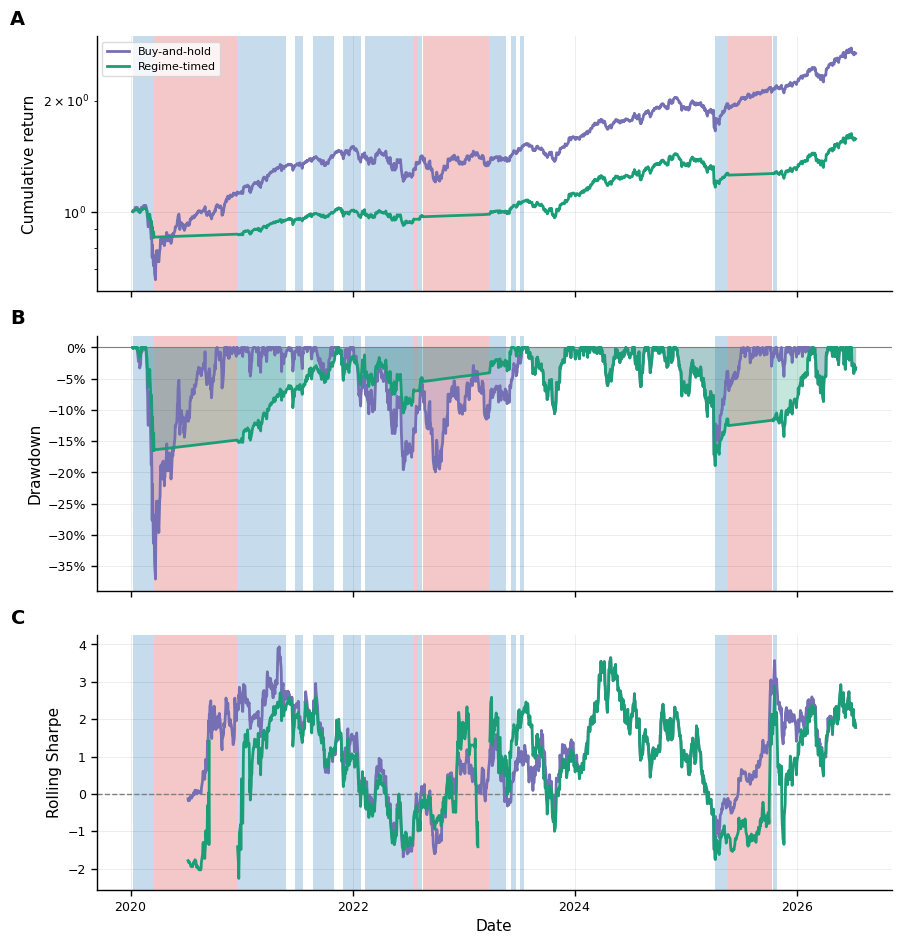

In [20]:
# Equity curve, drawdown, and rolling Sharpe, stacked on a shared date axis -- display only, not saved
transitional_spans = regime_spans(regime_daily_test, "Transitional")
LINEWIDTH = 2.0
GRID_ALPHA = 0.08
REGIME_SHADE_ALPHA = 0.25

fig, axes = plt.subplots(3, 1, figsize=(9, 9.5), sharex=True)
panel_letters = iter("ABC")

strategy_handles = []
for name, (_, ret) in STRATEGIES.items():
    line, = axes[0].plot((1 + ret).cumprod(), label=name, color=STRATEGY_COLOURS[name], linewidth=LINEWIDTH, zorder=3)
    strategy_handles.append(line)
axes[0].set_yscale("log")
axes[0].set_ylabel("Cumulative return")

for name, (_, ret) in STRATEGIES.items():
    dd = drawdown_series(ret)
    axes[1].fill_between(dd.index, dd.values, 0, color=STRATEGY_COLOURS[name], alpha=0.25, linewidth=0, zorder=1)
    axes[1].plot(dd, color=STRATEGY_COLOURS[name], linewidth=LINEWIDTH, zorder=3)
axes[1].axhline(0.0, color=NEUTRAL_COLOURS["reference"], linewidth=0.8, zorder=2)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[1].set_ylabel("Drawdown")

for name, (_, ret) in STRATEGIES.items():
    axes[2].plot(rolling_sharpe(ret, risk_free_daily), color=STRATEGY_COLOURS[name], linewidth=LINEWIDTH, zorder=3)
axes[2].axhline(0.0, color=NEUTRAL_COLOURS["reference"], linestyle="--", linewidth=1.0, zorder=2)
axes[2].set_ylabel("Rolling Sharpe")

for ax in axes:
    shade_periods(ax, transitional_spans, REGIME_PALETTE[1], alpha=REGIME_SHADE_ALPHA, zorder=0)
    shade_periods(ax, crisis_spans, REGIME_PALETTE[2], alpha=REGIME_SHADE_ALPHA, zorder=0)
    add_panel_label(ax, next(panel_letters), x=-0.09, y=1.03)
    format_date_axis(ax)
    style_axis(ax, grid=True)
    ax.grid(True, alpha=GRID_ALPHA)

axes[0].legend(handles=strategy_handles, loc="upper left", frameon=True,
               facecolor="white", edgecolor="lightgray", fontsize=8, ncol=1)
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

In [21]:
# Check the regime-timed strategy against the success criterion, verbatim from the top of this notebook
sharpe_beats_bah = metrics_table.loc["Regime-timed", "Sharpe"] > metrics_table.loc["Buy-and-hold", "Sharpe"]
mdd_beats_bah = metrics_table.loc["Regime-timed", "Max drawdown"] > metrics_table.loc["Buy-and-hold", "Max drawdown"]
sharpe_beats_bah_ex_covid = ex_covid_table.loc["Regime-timed", "Sharpe"] > ex_covid_table.loc["Buy-and-hold", "Sharpe"]
mdd_beats_bah_ex_covid = ex_covid_table.loc["Regime-timed", "Max drawdown"] > ex_covid_table.loc["Buy-and-hold", "Max drawdown"]
survives_ex_covid = sharpe_beats_bah_ex_covid and mdd_beats_bah_ex_covid

print(f"Sharpe beats buy-and-hold:               {sharpe_beats_bah}")
print(f"Max drawdown beats buy-and-hold:         {mdd_beats_bah}")
print(f"Sharpe advantage survives ex-COVID:      {sharpe_beats_bah_ex_covid}")
print(f"Max drawdown advantage survives ex-COVID:{mdd_beats_bah_ex_covid}")

Sharpe beats buy-and-hold:               False
Max drawdown beats buy-and-hold:         True
Sharpe advantage survives ex-COVID:      True
Max drawdown advantage survives ex-COVID:True
